# Comparison

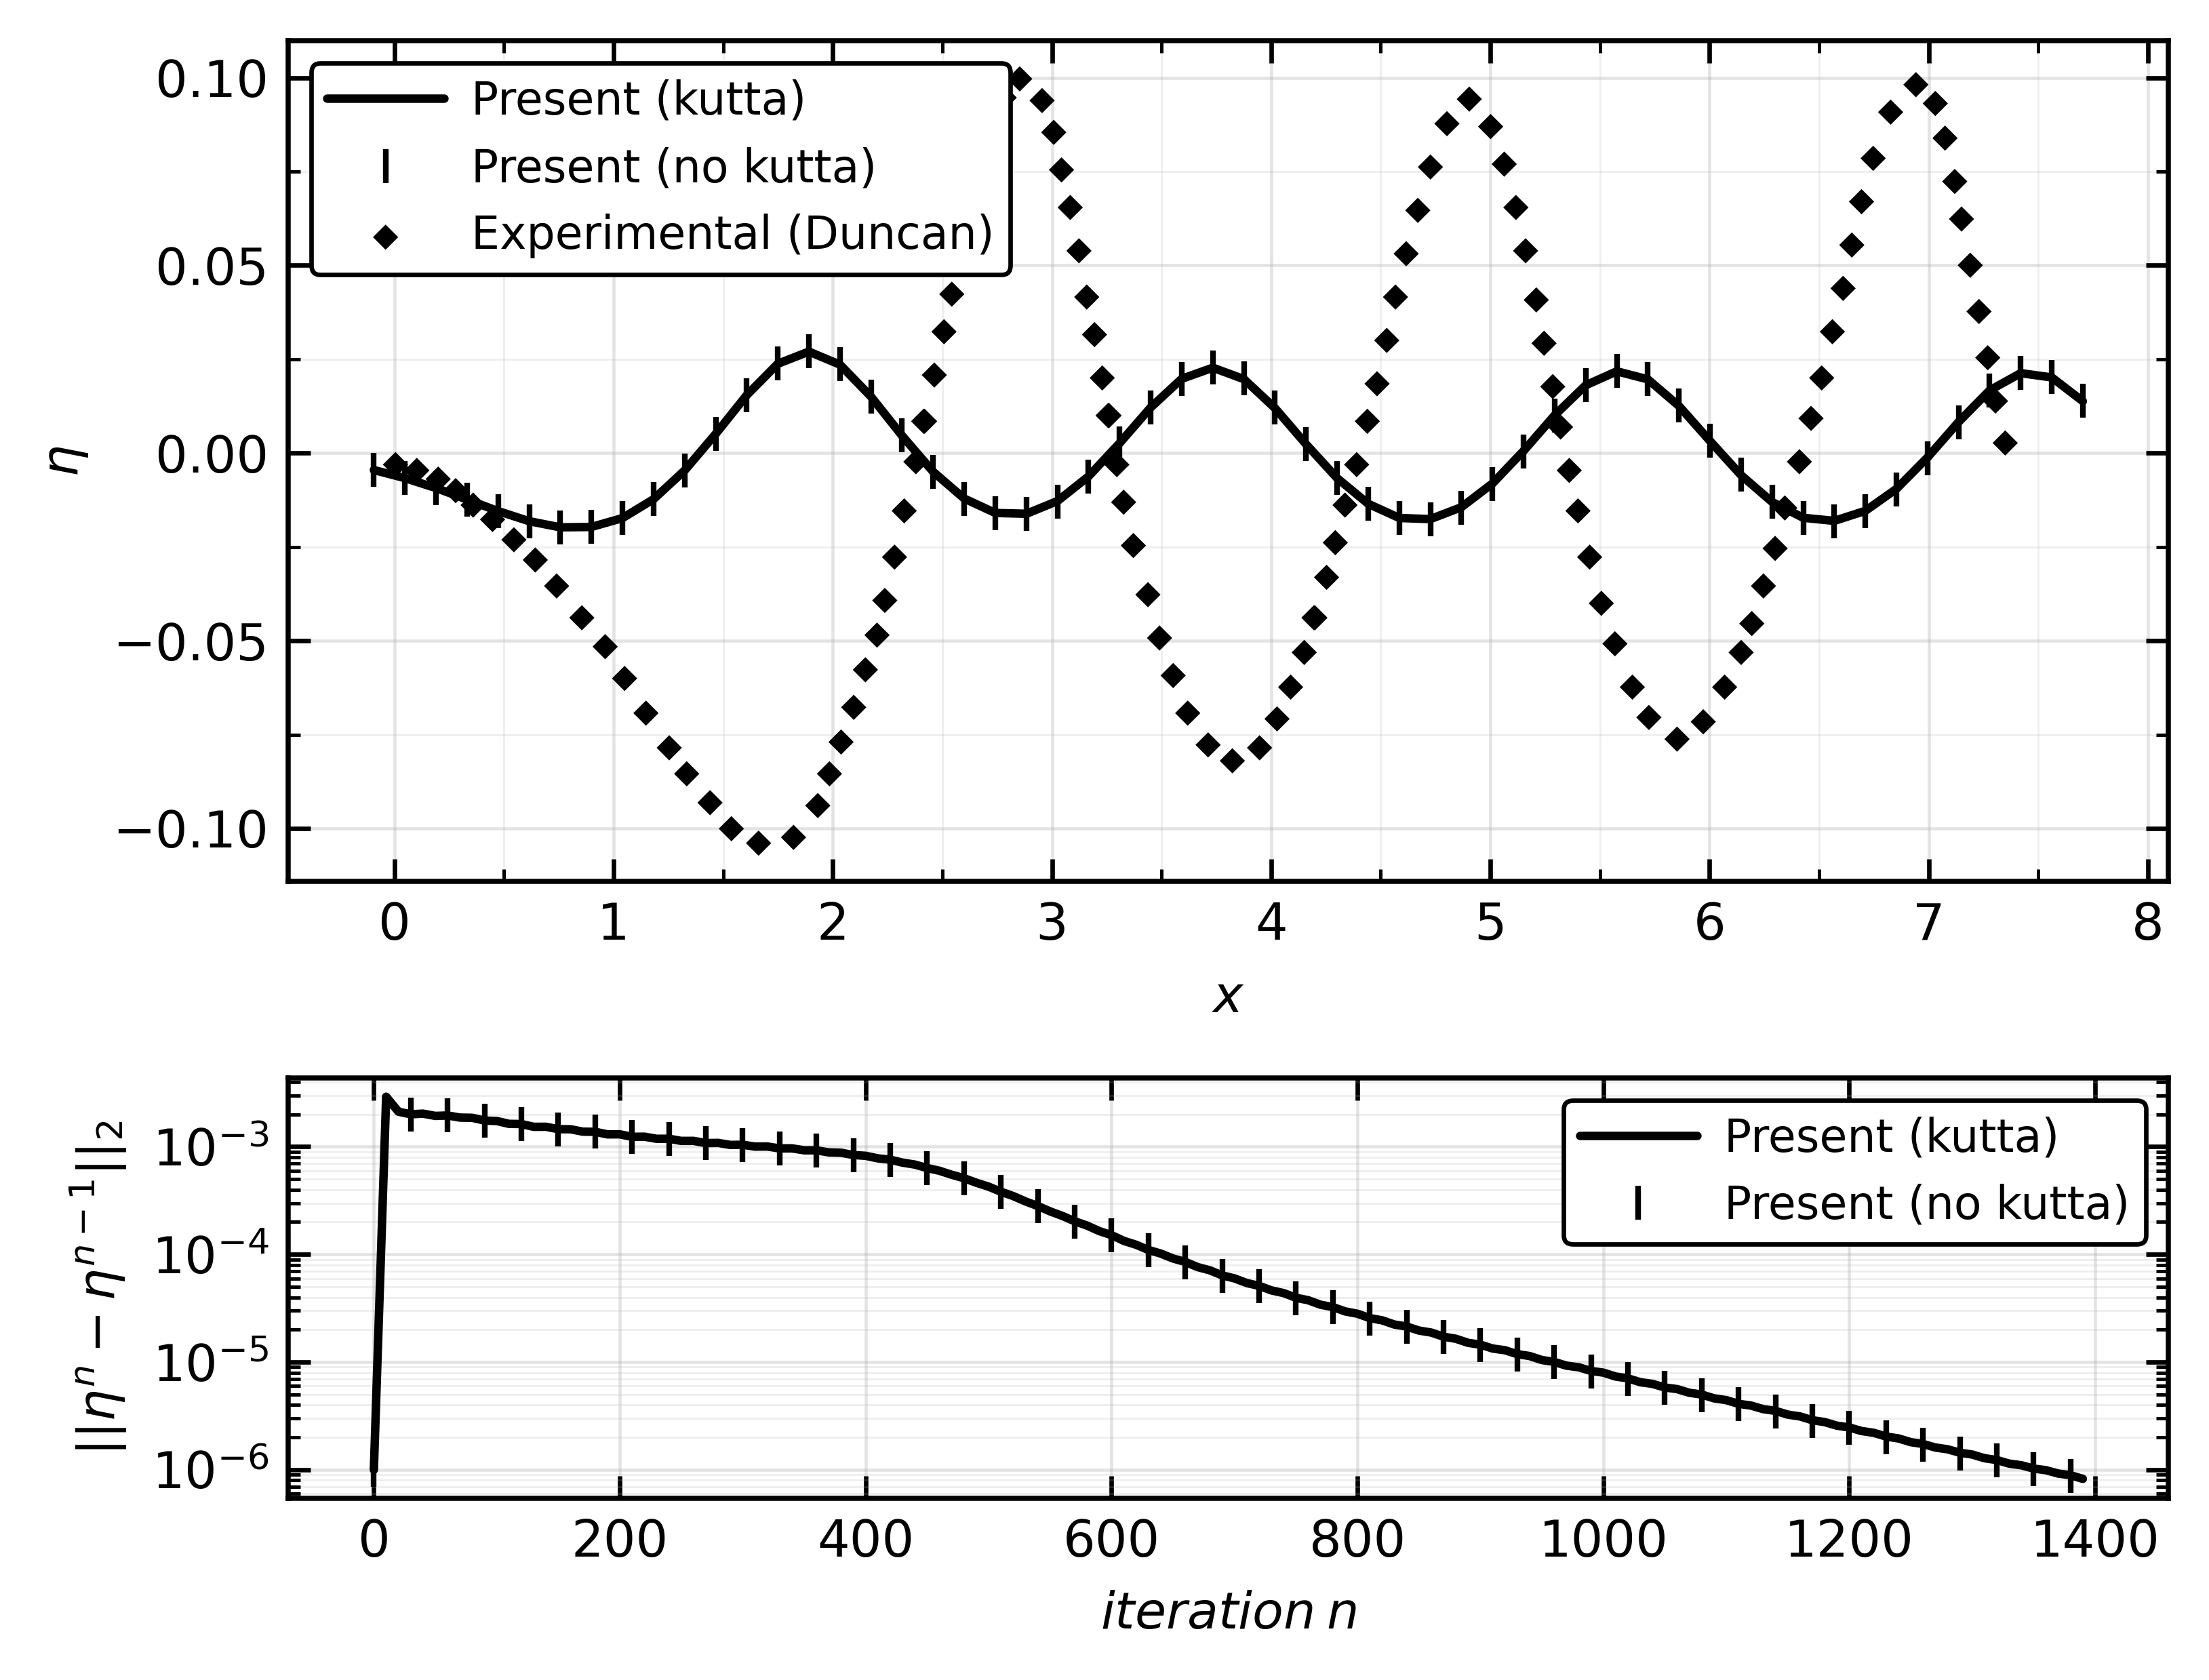

In [114]:
import os
if os.getcwd().endswith("Visualisation/Functional"):
    os.chdir("../../Functional/TestResults")

kutta_suffix = "5672Kutta"
no_kutta_suffix = "5672"

def comparison_plot(shift = 0.25, scale = 1):
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.ticker import AutoMinorLocator

    cd = 20.3 #chord duncan
    Duncan = np.loadtxt("../Benchmark/Duncan80cmsAoAh21.txt")
    Duncan = Duncan.T
    Duncan /= cd

    residuals = np.load("./arrays" + kutta_suffix +"/residuals" + kutta_suffix +".npy")
    residuals, time_step = residuals[:,0], residuals[:,1]
    eta = np.load("./arrays" + kutta_suffix + "/eta" + kutta_suffix +".npy")
    fs_xs = np.load("./arrays" + kutta_suffix + "/coordsFS" + kutta_suffix +".npy")
    time = np.where(time_step == 0)[0][0] - 1
    eta -= eta[0,0]
    eta = eta[time][:]
    fs_xs = fs_xs[time][:]
    eta = eta[np.argsort(fs_xs)]
    fs_xs = fs_xs[np.argsort(fs_xs)]
    x_start = np.where(np.abs(fs_xs + shift) == np.min(np.abs(fs_xs + shift)))[0][0] - 1
    x_stop  = np.where(fs_xs <= np.max(Duncan[0]))[0][-1] + 2
    fs_xs_s = fs_xs[x_start:x_stop]
    eta_s   = eta[x_start:x_stop]

    residuals_p = np.load("./arrays" + no_kutta_suffix +"/residuals" + no_kutta_suffix +".npy")
    residuals_p, time_step_p = residuals_p[:,0], residuals_p[:,1]
    eta_p = np.load("./arrays" + no_kutta_suffix + "/eta" + no_kutta_suffix +".npy")
    fs_xs_p = np.load("./arrays" + no_kutta_suffix + "/coordsFS" + no_kutta_suffix +".npy")
    time_p = np.where(time_step_p == 0)[0][0] - 1
    eta_p -= eta_p[0,0]
    eta_p = eta_p[time_p][:]
    fs_xs_p = fs_xs_p[time_p][:]
    eta_p = eta_p[np.argsort(fs_xs_p)]
    fs_xs_p = fs_xs_p[np.argsort(fs_xs_p)]
    x_start = np.where(np.abs(fs_xs_p + shift) == np.min(np.abs(fs_xs_p + shift)))[0][0] - 1
    x_stop  = np.where(fs_xs_p <= np.max(Duncan[0]))[0][-1] + 2
    fs_xs_p_s = fs_xs_p[x_start:x_stop]
    eta_p_s   = eta_p[x_start:x_stop]

    # ---- Same paper B/W style ----
    mpl.rcParams.update({
        "figure.dpi": 600,
        "savefig.dpi": 1000,
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.2,
        "ytick.minor.size": 2.2,
    })
    

    fig, ax = plt.subplots(2,1,
                           figsize=(5.5, 4.2),
                           gridspec_kw={"height_ratios": [2, 1]})#, "hspace": 0.25},)

    # ---- Present: solid line only ----
    ax[0].plot(
        fs_xs_s + shift, eta_s*scale,
        color="k",
        linestyle="-",
        label="Present (kutta)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    ax[0].plot(
        fs_xs_p_s + shift, eta_p_s*scale,
        color="k",
        linestyle="",
        marker = "|",
        markersize = 6,
        label="Present (no kutta)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    # ---- Experimental: solid diamonds (print-safe) ----
    x_exp, y_exp = Duncan
    ax[0].scatter(
        x_exp, y_exp,
        s=10,                 # adjust up/down depending on density
        marker="D",           # diamond
        facecolors="k",       # solid
        edgecolors="none",
        alpha=1,           # helps with overplotting; set to 1.0 if sparse
        rasterized=True,      # keeps PDF size manageable if many points
        label="Experimental (Duncan)",
        zorder=2,
    )

    # ---- Axes polish kutta ----
    ax[0].xaxis.set_minor_locator(AutoMinorLocator(2))
    ax[0].yaxis.set_minor_locator(AutoMinorLocator(2))

    ax[0].grid(True, which="major", axis="both", linewidth=0.55, alpha=0.35, zorder=0)
    ax[0].grid(True, which="minor", axis="both", linewidth=0.35, alpha=0.20, zorder=0)

    ax[0].set_xlabel(r"$x$")     # rename as appropriate
    ax[0].set_ylabel(r"$\eta$")

    leg = ax[0].legend(
        loc="best",
        frameon=True,
        edgecolor="k",
        facecolor="white",
        framealpha=1.0,
        borderpad=0.35,
        handlelength=2.6,
        handletextpad=0.6,
    )
    leg.get_frame().set_linewidth(0.8)


    ax[1].semilogy(
        np.arange(0,time,10), residuals[:time:10],
        color="k",
        linestyle="-",
        label="Present (kutta)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    ax[1].semilogy(
        np.arange(0,time_p,30), residuals_p[:time_p:30],
        color="k",
        linestyle="",
        marker = "|",
        markersize =6,
        label="Present (no kutta)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )
    
    # ---- Axes polish no kutta ----
    ax[1].grid(True, which="major", axis="both", linewidth=0.55, alpha=0.35, zorder=0)
    ax[1].grid(True, which="minor", axis="both", linewidth=0.35, alpha=0.20, zorder=0)

    ax[1].set_xlabel(r"$iteration\: n$")     # rename as appropriate
    ax[1].set_ylabel(r"$||\eta^n - \eta^{n-1}||_2$")

    leg = ax[1].legend(
        loc="best",
        frameon=True,
        edgecolor="k",
        facecolor="white",
        framealpha=1.0,
        borderpad=0.35,
        handlelength=2.6,
        handletextpad=0.6,
    )
    leg.get_frame().set_linewidth(0.8)

    fig.tight_layout()
    fig.savefig("../../Visualisation/Functional/comparison.pdf", bbox_inches="tight")  # recommended
    plt.show()
    return eta_p, eta
eta_no, eta_yes = comparison_plot()

Kutta: 192 seconds
no Kutta: 142 seconds

In [112]:
import numpy as np
np.linalg.norm(eta_no - eta_yes)

np.float64(0.000835084215707794)

# Mesh independance

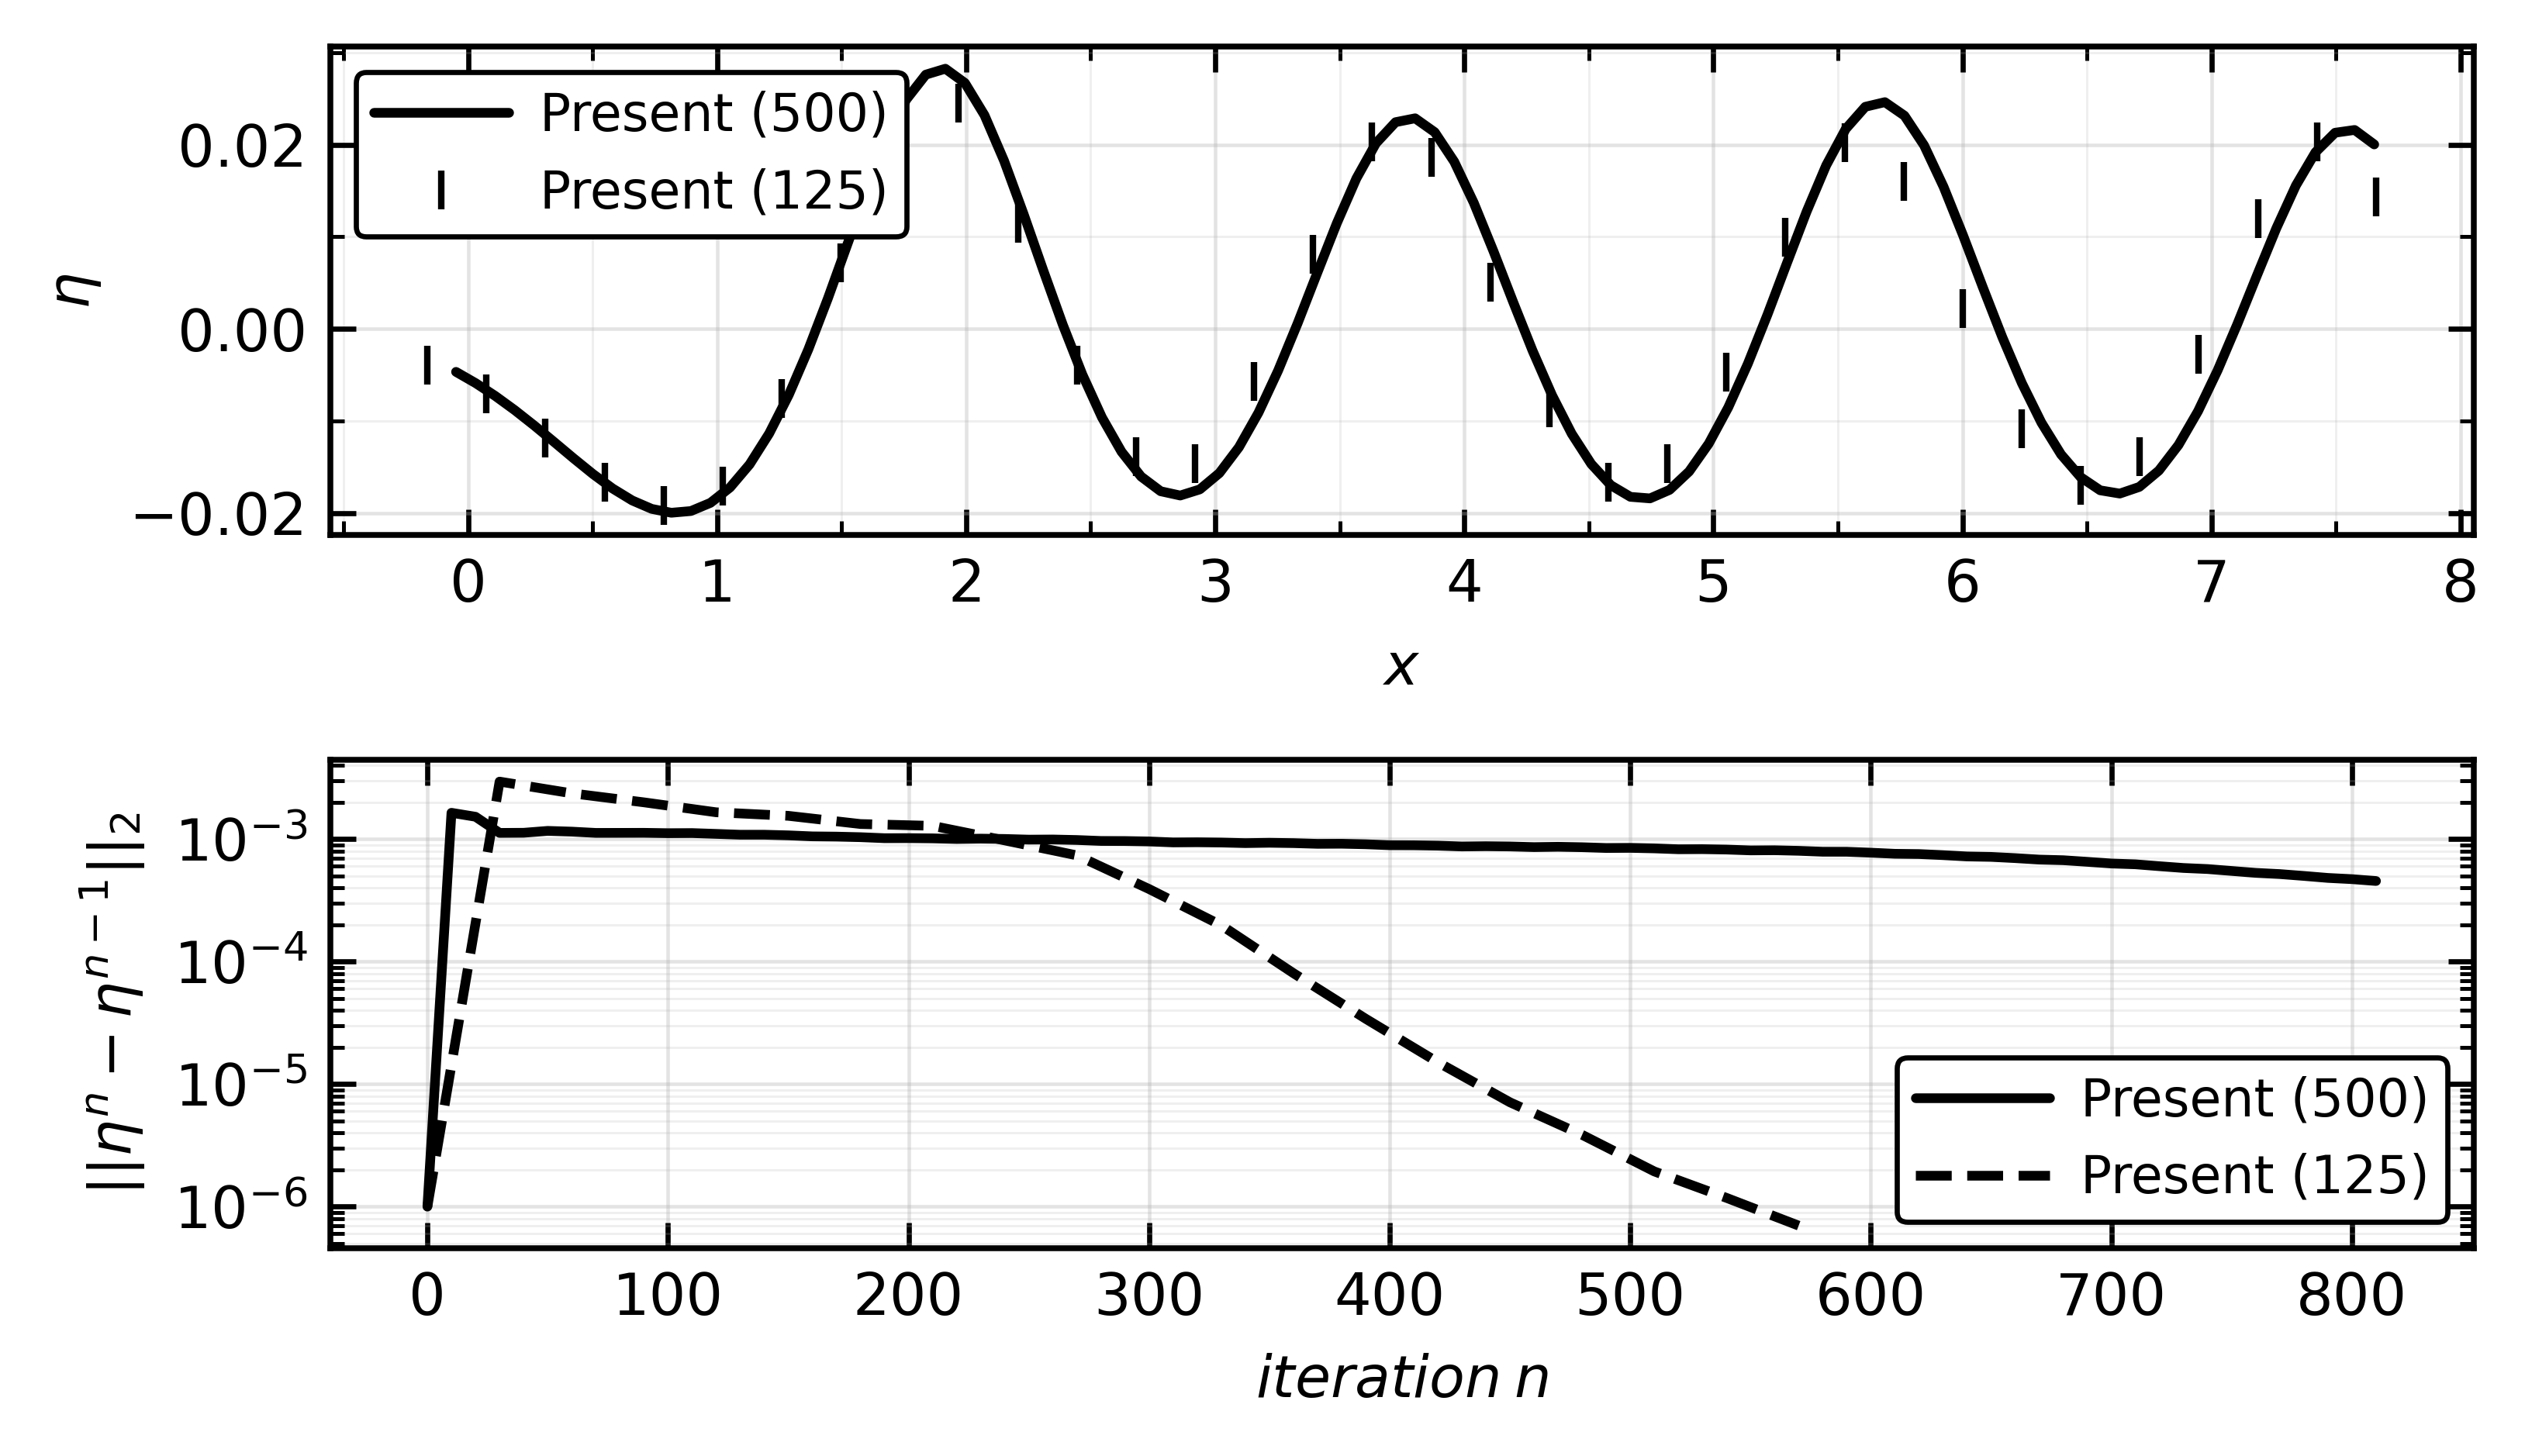

In [142]:
import os
if os.getcwd().endswith("Visualisation/Functional"):
    os.chdir("../../Functional/TestResults")

kutta_suffix = ""
no_kutta_suffix = "125"

def comparison_plot(shift = 0.25, scale = 1):
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.ticker import AutoMinorLocator

    cd = 20.3 #chord duncan
    Duncan = np.loadtxt("../Benchmark/Duncan80cmsAoAh21.txt")
    Duncan = Duncan.T
    Duncan /= cd

    residuals = np.load("./arrays" + kutta_suffix +"/residuals" + kutta_suffix +".npy")
    residuals, time_step = residuals[:,0], residuals[:,1]
    eta = np.load("./arrays" + kutta_suffix + "/eta" + kutta_suffix +".npy")
    fs_xs = np.load("./arrays" + kutta_suffix + "/coordsFS" + kutta_suffix +".npy")
    time = np.where(time_step == 0)[0][0] - 1
    eta -= eta[0,0]
    eta = eta[time][:]
    fs_xs = fs_xs[time][:]
    eta = eta[np.argsort(fs_xs)]
    fs_xs = fs_xs[np.argsort(fs_xs)]
    x_start = np.where(np.abs(fs_xs + shift) == np.min(np.abs(fs_xs + shift)))[0][0] - 1
    x_stop  = np.where(fs_xs <= np.max(Duncan[0]))[0][-1] + 2
    fs_xs_s = fs_xs[x_start:x_stop]
    eta_s   = eta[x_start:x_stop]

    residuals_p = np.load("./arrays" + no_kutta_suffix +"/residuals" + no_kutta_suffix +".npy")
    residuals_p, time_step_p = residuals_p[:,0], residuals_p[:,1]
    eta_p = np.load("./arrays" + no_kutta_suffix + "/eta" + no_kutta_suffix +".npy")
    fs_xs_p = np.load("./arrays" + no_kutta_suffix + "/coordsFS" + no_kutta_suffix +".npy")
    time_p = np.where(time_step_p == 0)[0][0] - 1
    eta_p -= eta_p[0,0]
    eta_p = eta_p[time_p][:]
    fs_xs_p = fs_xs_p[time_p][:]
    eta_p = eta_p[np.argsort(fs_xs_p)]
    fs_xs_p = fs_xs_p[np.argsort(fs_xs_p)]
    x_start = np.where(np.abs(fs_xs_p + shift) == np.min(np.abs(fs_xs_p + shift)))[0][0] - 1
    x_stop  = np.where(fs_xs_p <= np.max(Duncan[0]))[0][-1] + 2
    fs_xs_p_s = fs_xs_p[x_start:x_stop]
    eta_p_s   = eta_p[x_start:x_stop]

    # ---- Same paper B/W style ----
    mpl.rcParams.update({
        "figure.dpi": 600,
        "savefig.dpi": 1000,
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.2,
        "ytick.minor.size": 2.2,
    })
    

    fig, ax = plt.subplots(2,1,
                           figsize=(5.5, 3.2),
                           gridspec_kw={"height_ratios": [1, 1]})#, "hspace": 0.25},)

    # ---- Present: solid line only ----
    ax[0].plot(
        fs_xs_s + shift, eta_s*scale,
        color="k",
        linestyle="-",
        label="Present (500)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    ax[0].plot(
        fs_xs_p_s + shift, eta_p_s*scale,
        color="k",
        linestyle="",
        marker = "|",
        markersize = 6,
        label="Present (125)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    # ---- Experimental: solid diamonds (print-safe) ----
    x_exp, y_exp = Duncan
    # ax[0].scatter(
        # x_exp, y_exp,
        # s=10,                 # adjust up/down depending on density
        # marker="D",           # diamond
        # facecolors="k",       # solid
        # edgecolors="none",
        # alpha=1,           # helps with overplotting; set to 1.0 if sparse
        # rasterized=True,      # keeps PDF size manageable if many points
        # label="Experimental (Duncan)",
        # zorder=2,
    # )

    # ---- Axes polish kutta ----
    ax[0].xaxis.set_minor_locator(AutoMinorLocator(2))
    ax[0].yaxis.set_minor_locator(AutoMinorLocator(2))

    ax[0].grid(True, which="major", axis="both", linewidth=0.55, alpha=0.35, zorder=0)
    ax[0].grid(True, which="minor", axis="both", linewidth=0.35, alpha=0.20, zorder=0)

    ax[0].set_xlabel(r"$x$")     # rename as appropriate
    ax[0].set_ylabel(r"$\eta$")

    leg = ax[0].legend(
        loc="best",
        frameon=True,
        edgecolor="k",
        facecolor="white",
        framealpha=1.0,
        borderpad=0.35,
        handlelength=2.6,
        handletextpad=0.6,
    )
    leg.get_frame().set_linewidth(0.8)


    ax[1].semilogy(
        np.arange(0,time,10), residuals[:time:10],
        color="k",
        linestyle="-",
        label="Present (500)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )

    ax[1].semilogy(
        np.arange(0,time_p,30), residuals_p[:time_p:30],
        color="k",
        linestyle="--",
        marker = "",
        markersize =6,
        label="Present (125)",
        alpha = 1,
        lw = 1.5,
        zorder=3,
    )
    
    # ---- Axes polish no kutta ----
    ax[1].grid(True, which="major", axis="both", linewidth=0.55, alpha=0.35, zorder=0)
    ax[1].grid(True, which="minor", axis="both", linewidth=0.35, alpha=0.20, zorder=0)

    ax[1].set_xlabel(r"$iteration\: n$")     # rename as appropriate
    ax[1].set_ylabel(r"$||\eta^n - \eta^{n-1}||_2$")

    leg = ax[1].legend(
        loc="best",
        frameon=True,
        edgecolor="k",
        facecolor="white",
        framealpha=1.0,
        borderpad=0.35,
        handlelength=2.6,
        handletextpad=0.6,
    )
    leg.get_frame().set_linewidth(0.8)

    fig.tight_layout()
    fig.savefig("../../Visualisation/Functional/meshIndependance.pdf", bbox_inches="tight")  # recommended
    plt.show()
    return eta_p, eta
eta_no, eta_yes = comparison_plot()

120: 30s
